# Making other spatial variables for my regression analysis

The variables I make in this notebook are:
1. Distance to nearest CTA Station
2. Distance from Central Business District (the loop)
3. Distance to nearest public open space
4. Distance to Lake Michigan
5. Distance to the Chicago River

In [1]:
import geopandas as gpd
import shapely
from shapely import Point, LineString, Polygon
from plotnine import *

<hr>

## 1. Distance to Nearest CTA Station
Based on [this data](https://data.cityofchicago.org/Transportation/CTA-L-Rail-Stations/3tzw-cg4m/data_preview) (https://data.cityofchicago.org/Transportation/CTA-L-Rail-Stations/3tzw-cg4m/data_preview) from the City of Chicago

In [2]:
df = gpd.read_file('data/nb3_buildings_coded.geojson')

In [3]:
df.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467...."
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120...."
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774...."
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899...."
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337...."


In [4]:
df_cta_stations = gpd.read_file('notebook_5_data/1_cta_station_points.csv')

In [5]:
df_cta_stations.head()

,the_geom,STATION_ID,LONGNAME,LINES,ADDRESS,ADA,PKNRD,POINT_X,POINT_Y,LEGEND
0,POINT (-87.74517217791391 41.871608050522994),970,Cicero-Congress,Blue Line (Congress),720 S. Cicero Avenue,false,false,"1,144,440.97667316","1,896,352.78926296",Blue Line
1,POINT (-87.80317598719213 41.88684830347631),20,Harlem-Lake,Green Line (Lake),1 S. Harlem Avenue,true,false,"1,128,608.76033842","1,901,803.39560403",Green Line
2,POINT (-87.78366103293801 41.88715939826551),610,Ridgeland,Green Line (Lake),36 N. Ridgeland Avenue,false,false,"1,133,921.86037537","1,901,950.19138017",Green Line
3,POINT (-87.83802598504772 41.984294057828016),230,Cumberland,Blue Line,5800 N. Cumberland Avenue,true,true,"1,118,914.13069739","1,937,256.04587705",Blue Line
4,POINT (-87.62618878473234 41.88322001293653),1700,Washington/Wabash,"Brown, Orange, Pink, Purple (Express), Green",29 N. Wabash,true,false,"1,176,812.47724731","1,900,828.68763513",Multiple Lines


In [6]:
df_cta_stations['the_geom'] = df_cta_stations['the_geom'].str.replace('POINT (', '')
df_cta_stations['the_geom'] = df_cta_stations['the_geom'].str.replace(')', '')
df_cta_stations[['lon', 'lat']] = df_cta_stations['the_geom'].str.split(" ", expand=True)
df_cta_stations.head()

,the_geom,STATION_ID,LONGNAME,LINES,ADDRESS,ADA,PKNRD,POINT_X,POINT_Y,LEGEND,lon,lat
0,-87.74517217791391 41.871608050522994,970,Cicero-Congress,Blue Line (Congress),720 S. Cicero Avenue,false,false,"1,144,440.97667316","1,896,352.78926296",Blue Line,-87.74517217791391,41.871608050522994
1,-87.80317598719213 41.88684830347631,20,Harlem-Lake,Green Line (Lake),1 S. Harlem Avenue,true,false,"1,128,608.76033842","1,901,803.39560403",Green Line,-87.80317598719213,41.88684830347631
2,-87.78366103293801 41.88715939826551,610,Ridgeland,Green Line (Lake),36 N. Ridgeland Avenue,false,false,"1,133,921.86037537","1,901,950.19138017",Green Line,-87.78366103293801,41.88715939826551
3,-87.83802598504772 41.984294057828016,230,Cumberland,Blue Line,5800 N. Cumberland Avenue,true,true,"1,118,914.13069739","1,937,256.04587705",Blue Line,-87.83802598504772,41.984294057828016
4,-87.62618878473234 41.88322001293653,1700,Washington/Wabash,"Brown, Orange, Pink, Purple (Express), Green",29 N. Wabash,true,false,"1,176,812.47724731","1,900,828.68763513",Multiple Lines,-87.62618878473234,41.88322001293653


In [7]:
df_cta_stations_real = gpd.GeoDataFrame(df_cta_stations, geometry=gpd.points_from_xy(df_cta_stations['lon'], df_cta_stations['lat']))
df_cta_stations_real = df_cta_stations_real.set_crs(epsg=4326)
df_cta_stations_real = df_cta_stations_real.to_crs(epsg=26971)

In [8]:
print(df_cta_stations_real.crs)
print(df.crs)

EPSG:26971
EPSG:26971


In [9]:
df_joined = gpd.sjoin_nearest(
    df,
    df_cta_stations_real,
    how="left",
    distance_col="distance_to_cta_station"
)

In [10]:
df_joined.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,index_right,the_geom,STATION_ID,LONGNAME,LINES,ADDRESS,ADA,PKNRD,POINT_X,POINT_Y,LEGEND,lon,lat,distance_to_cta_station
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467....",87,-87.62441474538349 41.722375984242476,450,95th/Dan Ryan,Red Line,14 W. 95th Street,true,false,"1,177,778.98067221","1,842,222.00572454",Red Line,-87.62441474538349,41.722375984242476,3860.182377
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120....",69,-87.76089227927595 41.97063413812226,1280,Jefferson Park,Blue Line,4917 N. Milwaukee Avenue,true,false,"1,139,918.57154895","1,932,409.02840054",Blue Line,-87.76089227927595,41.97063413812226,2582.009645
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774....",33,-87.79378335175879 41.8869875216134,1350,Oak Park-Lake,Green Line (Lake),100 S. Oak Park Avenue,false,false,"1,131,166.0096208","1,901,870.0672201",Green Line,-87.79378335175879,41.8869875216134,4980.283463
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899....",55,-87.72444964277845 41.79988782039872,960,Pulaski-Midway,Orange Line,5106 S. Pulaski Road,true,true,"1,150,270.22237459","1,870,257.60178265",Orange Line,-87.72444964277845,41.79988782039872,1005.853891
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337....",106,-87.6638448484402 41.77895340563769,290,Ashland/63rd,Green Line (Englewood),6315 S. Ashland Avenue,true,true,"1,166,854.40799004","1,862,752.12183966",Green Line,-87.6638448484402,41.77895340563769,2607.825343


In [11]:
df_joined = df_joined.drop(columns=['index_right', 'the_geom', 'STATION_ID', 'LONGNAME', 'LINES', 'ADDRESS', 'ADA', 'PKNRD', 'POINT_X', 'POINT_Y', 'LEGEND', 'lon', 'lat'])

In [14]:
df_joined.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,distance_to_cta_station
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467....",3860.182377
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120....",2582.009645
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774....",4980.283463
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899....",1005.853891
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337....",2607.825343


/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 214'. Pick better value with 'binwidth'.


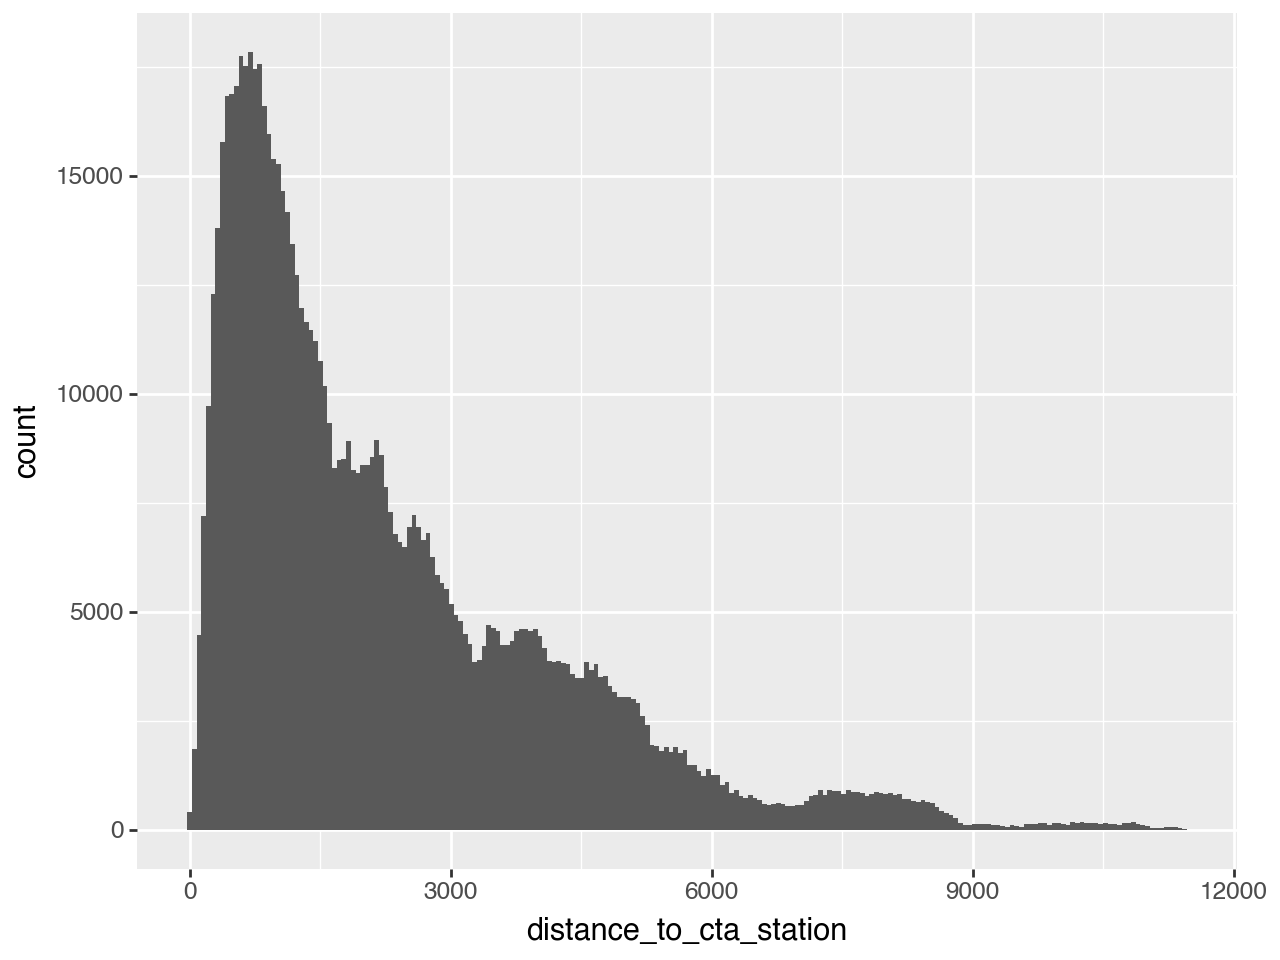

In [15]:
plot = (
    ggplot(df_joined) +
    aes(x='distance_to_cta_station') +
    geom_histogram()
)
plot

<hr>

## 2. Distance to Central Business District
Based on [this data](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Central-Business-District/tksj-nvsw) (https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Central-Business-District/tksj-nvsw) from the City of Chicago

In [16]:
chi_biz_dist = gpd.read_file('notebook_5_data/2_central_business_district.geojson')
chi_biz_dist.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [17]:
chi_biz_dist_projected = chi_biz_dist.to_crs(epsg=26971)

In [18]:
print(chi_biz_dist_projected.crs)
print(df_joined.crs)

EPSG:26971
EPSG:26971


In [19]:
df_joined['distance_to_chi_center'] = df_joined.distance(chi_biz_dist_projected.geometry.iloc[0])

In [20]:
df_joined.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,distance_to_cta_station,distance_to_chi_center
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467....",3860.182377,17732.852973
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120....",2582.009645,12757.264762
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774....",4980.283463,12682.222674
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899....",1005.853891,9795.750590
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337....",2607.825343,12490.906160


/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 174'. Pick better value with 'binwidth'.


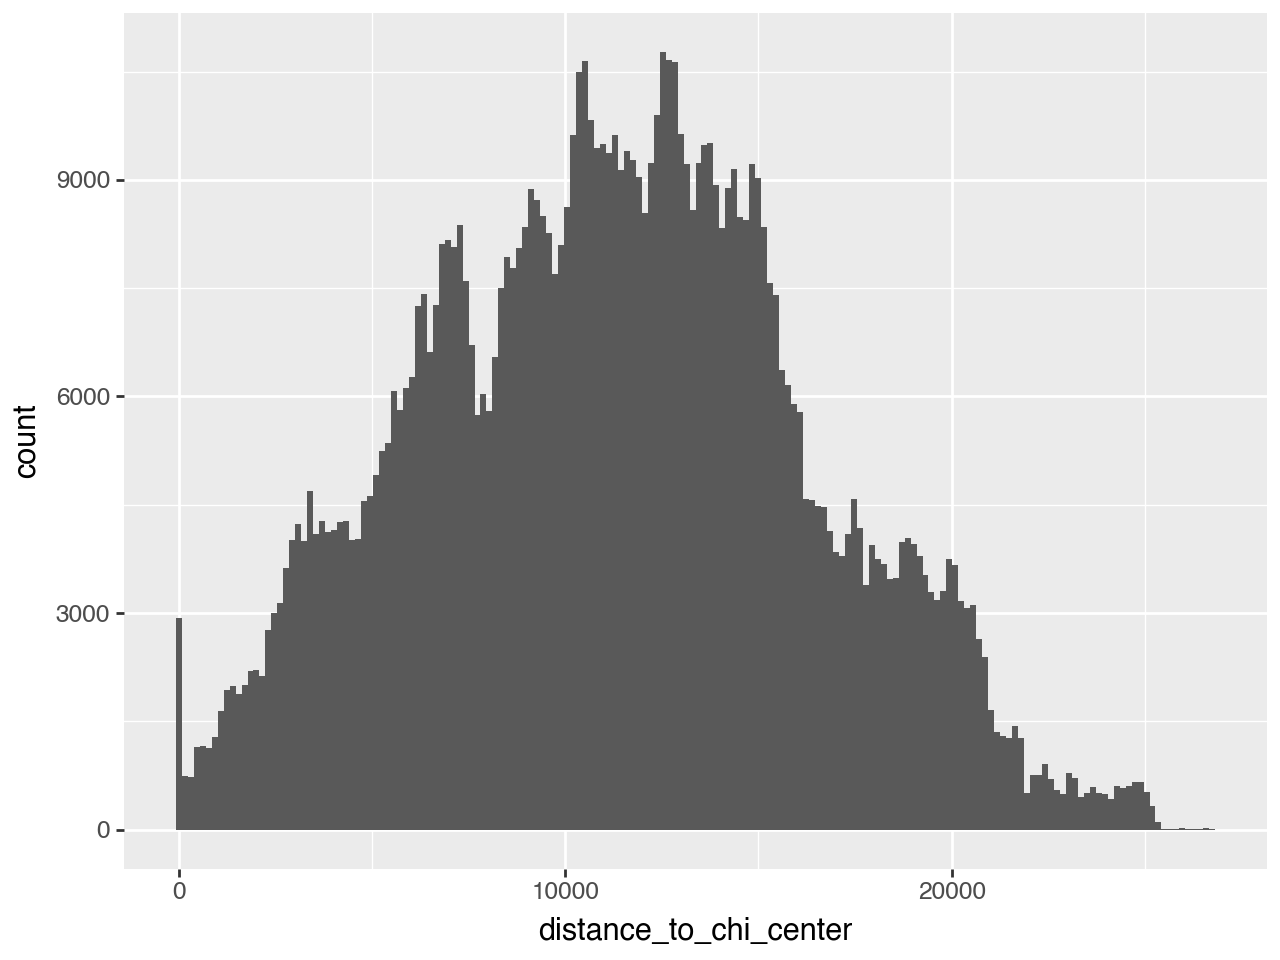

In [21]:
plot = (
    ggplot(df_joined) +
    aes(x='distance_to_chi_center') +
    geom_histogram()
)
plot

<hr>

## 3. Distance to Nearest Public Open Area

Based on [this data](https://data.cityofchicago.org/Parks-Recreation/Parks-Chicago-Park-District-Park-Boundaries-curren/ej32-qgdr) (https://data.cityofchicago.org/Parks-Recreation/Parks-Chicago-Park-District-Park-Boundaries-curren/ej32-qgdr) from the City of Chicago

In [22]:
df_parks = gpd.read_file('notebook_5_data/3_parks.geojson')

In [23]:
df_parks.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [24]:
df_parks_projected = df_parks.to_crs(epsg=26971)

In [25]:
print(df_parks_projected.crs)
print(df_joined.crs)

EPSG:26971
EPSG:26971


In [26]:
parks_joined = df_parks_projected.geometry.union_all()

In [27]:
df_joined['distance_to_park'] = df_joined.distance(parks_joined)

In [28]:
df_joined.sort_values('distance_to_park', ascending=False)

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,distance_to_cta_station,distance_to_chi_center,distance_to_park
517620,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((332611.118 592101.104, 332610....",3857.493170,26741.894139,8620.547498
666290,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((332605.174 592004.025, 332603....",3821.867148,26722.924433,8618.947033
252746,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((332616.147 591966.992, 332604....",3791.982282,26698.120114,8600.906065
290346,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((332615.995 591958, 332603.955 ...",3787.087995,26694.509038,8598.913246
288515,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((332615.538 591954.952, 332606....",3785.769142,26693.654162,8598.633705
...,...,...,...,...,...,...,...,...,...
34302,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((357878.479 588107.667, 357881....",1872.512391,6431.575225,0.000000
271059,205.126383,79979.057837,0.0,0.0,3,"MULTIPOLYGON (((354393.663 582777.192, 354394....",459.888399,3138.094111,0.000000
729086,0.000000,0.000000,0.0,0.0,0,"MULTIPOLYGON (((365917.443 562788.277, 365917....",6971.391846,16218.529653,0.000000
306491,65.759297,31782.278971,0.0,0.0,4,"MULTIPOLYGON (((356672.535 578935.242, 356671....",438.732569,225.845009,0.000000


/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 1246'. Pick better value with 'binwidth'.


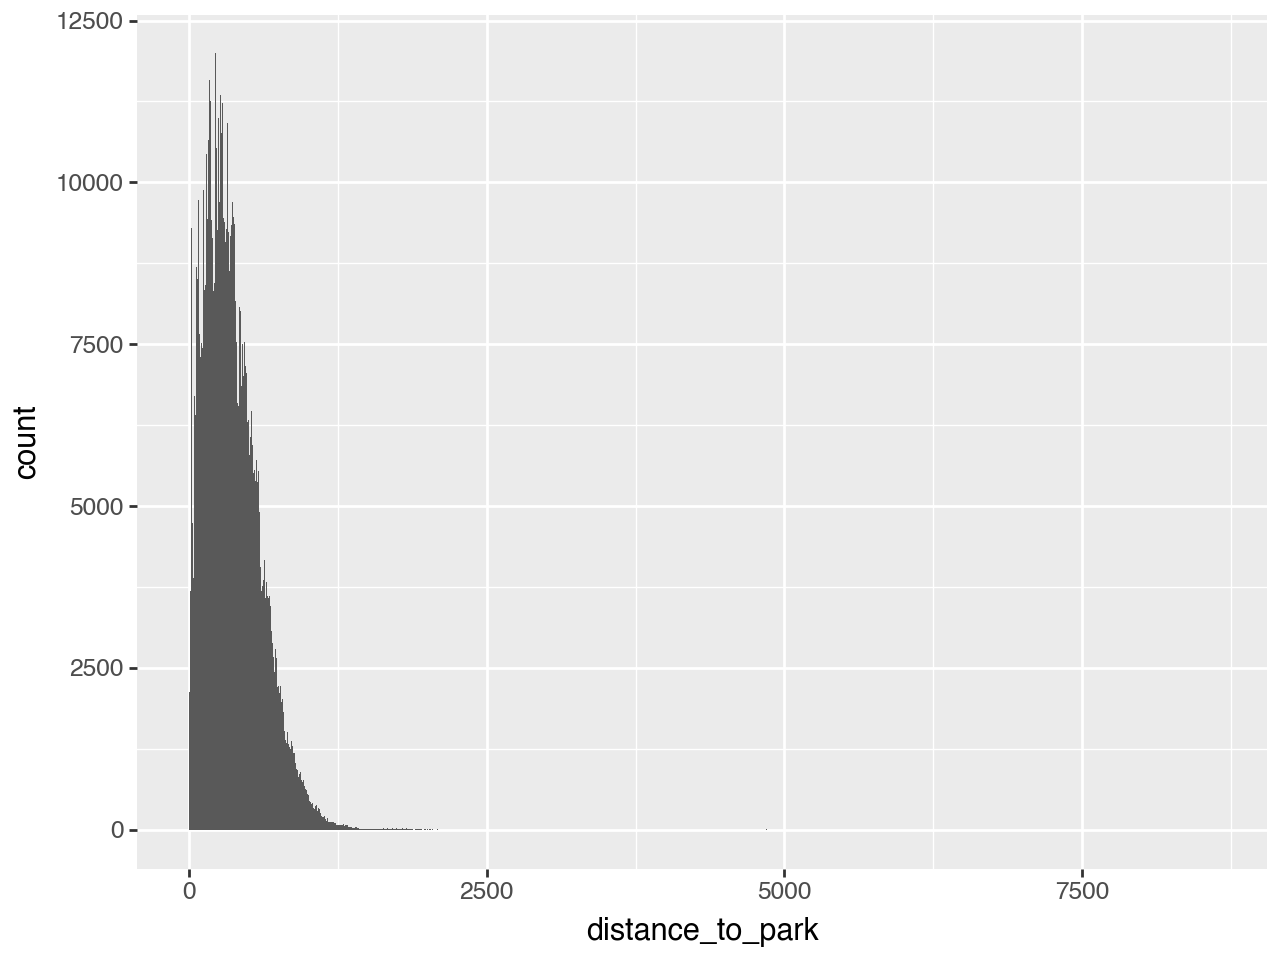

In [29]:
plot = (
    ggplot(df_joined) +
    aes(x='distance_to_park') +
    geom_histogram()
)
plot

<hr>

## 4. Distance to Lake Michigan
Based on [this data](https://data.cityofchicago.org/Parks-Recreation/Waterways/eg9f-z3t6) (https://data.cityofchicago.org/Parks-Recreation/Waterways/eg9f-z3t6) from the City of Chicago

In [30]:
df_waterways = gpd.read_file('notebook_5_data/4_5_waterways.geojson')

In [31]:
lake_michigan = df_waterways[df_waterways['name'].str.contains('LAKE MICHIGAN')].geometry
lake_michigan_projected = lake_michigan.to_crs(epsg=26971)

In [32]:
print(lake_michigan_projected.crs)
print(df_joined.crs)

EPSG:26971
EPSG:26971


In [33]:
df_joined['distance_to_lake_michigan'] = df_joined.distance(lake_michigan_projected.iloc[0])

In [34]:
df_joined.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,distance_to_cta_station,distance_to_chi_center,distance_to_park,distance_to_lake_michigan
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467....",3860.182377,17732.852973,426.726988,10709.464139
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120....",2582.009645,12757.264762,223.826372,7084.578945
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774....",4980.283463,12682.222674,348.577527,12655.612846
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899....",1005.853891,9795.750590,114.080421,11050.709236
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337....",2607.825343,12490.906160,456.949618,8035.384817


<hr>

## 5. Distance to the Chicago River
Based on [this data](https://data.cityofchicago.org/Parks-Recreation/Waterways/eg9f-z3t6) (https://data.cityofchicago.org/Parks-Recreation/Waterways/eg9f-z3t6) from the City of Chicago

In [35]:
chicago_river_long = df_waterways[df_waterways['name'].str.contains('CHICAGO RIVER')]
chicago_river_long.head()

,:id,:version,:created_at,:updated_at,display,name,edit_date1,fid_,shape_area,shape_len,geometry
4,row-kfwr_q5ru.gaij,rv-ebze~qdkh_9xsz,2015-12-02 17:40:09.464000+00:00,2015-12-02 17:40:09.464000+00:00,1,SOUTH BRANCH CHICAGO RIVER,03-23-01,None,7238.91845,434.296024099,"MULTIPOLYGON (((-87.66433 41.8401, -87.66433 4..."
6,row-h8xa.bdjp.pzsq,rv-8kpg.28fp-2s5k,2015-12-02 17:40:09.464000+00:00,2015-12-02 17:40:09.464000+00:00,1,SOUTH BRANCH CHICAGO RIVER,03-23-01,None,8398.64405,452.647366302,"MULTIPOLYGON (((-87.66432 41.8399, -87.66432 4..."
8,row-ktmq-2mcq.6nsd,rv-yxkx-y8rh~sgu8,2015-12-02 17:40:09.464000+00:00,2015-12-02 17:40:09.464000+00:00,1,SOUTH BRANCH CHICAGO RIVER,03-23-01,None,10717.88845,480.879643381,"MULTIPOLYGON (((-87.66418 41.83947, -87.6641 4..."
10,row-xt4p.8v2b-bqci,rv-9dwk~gte6~8aki,2015-12-02 17:40:09.464000+00:00,2015-12-02 17:40:09.464000+00:00,1,SOUTH BRANCH CHICAGO RIVER,03-23-01,None,10484.5497,470.741271808,"MULTIPOLYGON (((-87.66409 41.83928, -87.66401 ..."
12,row-9bni.szhb.ym74,rv-hd7x.mxht.nbqy,2015-12-02 17:40:09.464000+00:00,2015-12-02 17:40:09.464000+00:00,1,SOUTH BRANCH CHICAGO RIVER,03-23-01,None,13876.01,489.66726867,"MULTIPOLYGON (((-87.6639 41.83892, -87.66377 4..."


In [36]:
chicago_river_long['name'].value_counts()

name
NORTH BRANCH CHICAGO RIVER    73
SOUTH BRANCH CHICAGO RIVER    44
CHICAGO RIVER                 25
Name: count, dtype: int64

In [37]:
chicago_river_long.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [38]:
chicago_river_projected = chicago_river_long.to_crs(epsg=26971)

In [39]:
chicago_river_joined = chicago_river_projected.geometry.union_all()

In [40]:
df_joined['distance_to_river'] = df_joined.distance(chicago_river_joined)

In [41]:
df_joined.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,distance_to_cta_station,distance_to_chi_center,distance_to_park,distance_to_lake_michigan,distance_to_river
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467....",3860.182377,17732.852973,426.726988,10709.464139,12958.068724
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120....",2582.009645,12757.264762,223.826372,7084.578945,798.282752
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774....",4980.283463,12682.222674,348.577527,12655.612846,6392.788209
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899....",1005.853891,9795.750590,114.080421,11050.709236,6523.256369
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337....",2607.825343,12490.906160,456.949618,8035.384817,7697.437777


/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 142'. Pick better value with 'binwidth'.


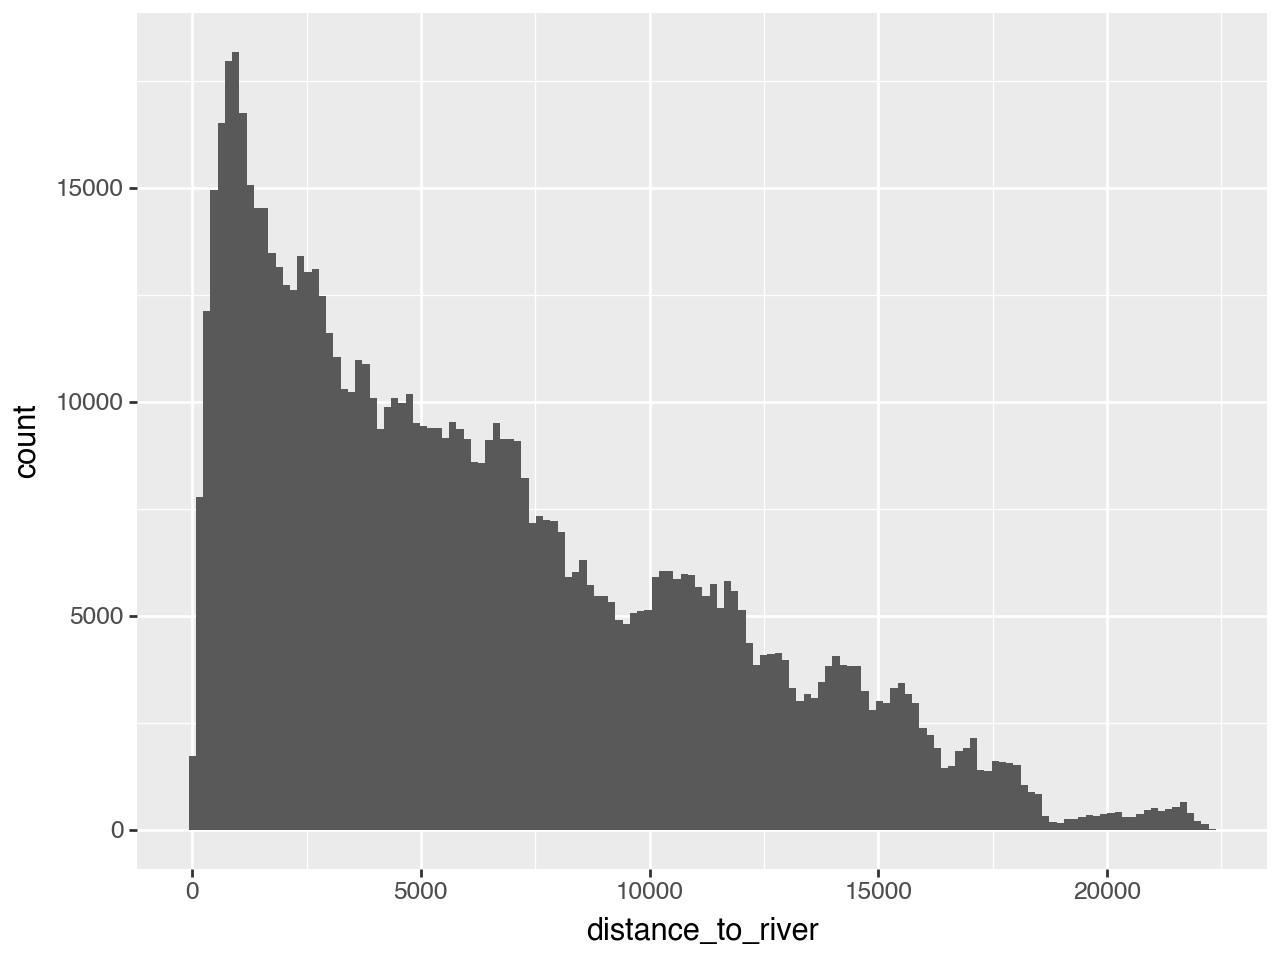

In [42]:
plot = (
    ggplot(df_joined) +
    aes(x='distance_to_river') +
    geom_histogram()
)
plot

<hr>

## Exporting Finished Data

In [43]:
df_joined.head()

,noise_from_one_train,daily_noise,intersected_noise_from_one_train,intersected_daily_noise,num_radials,geometry,distance_to_cta_station,distance_to_chi_center,distance_to_park,distance_to_lake_michigan,distance_to_river
0,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355479.089 559882.918, 355467....",3860.182377,17732.852973,426.726988,10709.464139,12958.068724
1,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349120.643 590966.331, 349120....",2582.009645,12757.264762,223.826372,7084.578945,798.282752
2,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((344774.948 584671.437, 344774....",4980.283463,12682.222674,348.577527,12655.612846,6392.788209
3,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((349899.866 570780.758, 349899....",1005.853891,9795.750590,114.080421,11050.709236,6523.256369
4,0.0,0.0,0.0,0.0,0,"MULTIPOLYGON (((355337.813 565171.665, 355337....",2607.825343,12490.906160,456.949618,8035.384817,7697.437777


In [44]:
df_joined.to_file('data/nb5_buildings_full.geojson', driver='GeoJSON', crs=df_joined.crs, engine="fiona")

df_joined.to_csv('data/nb3_buildings_coded.csv', index=False)